In [2]:
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import RMSprop
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, fbeta_score, cohen_kappa_score
from imblearn.over_sampling import SMOTE
from tqdm import tqdm
import cv2
import os
import time as t


In [2]:
# Ensure GPU memory is managed effectively
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [3]:
# Load the CSV file
train_csv_path = 'MURA-v1.1/train_image_paths_with_labels.csv'
train_data = pd.read_csv(train_csv_path)

valid_csv_path= 'MURA-v1.1/valid_image_paths_with_labels.csv'
valid_data=pd.read_csv(valid_csv_path)


In [4]:

# Load the pre-trained VGG16 model and exclude the top classification layer
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model = Model(inputs=base_model.input, outputs=base_model.output)


In [5]:

def load_and_preprocess_image(path):
    image = load_img(path, target_size=(224, 224))
    image = img_to_array(image)
    image = preprocess_input(image)  # Normalize the image
    return image



In [6]:

# Load images and extract features
def extract_features(df, model, batch_size=16):
    features = []
    labels = []
    batch_images = []
    batch_labels = []

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        image_path = row['path']
        label = row['label']
        image = load_and_preprocess_image(image_path)
        batch_images.append(image)
        batch_labels.append(1 if label == 'positive' else 0)

        if len(batch_images) == batch_size:
            batch_images = np.array(batch_images)
            batch_features = model.predict(batch_images)
            features.extend(batch_features)
            labels.extend(batch_labels)
            batch_images, batch_labels = [], []

            # Clear the GPU memory
            tf.keras.backend.clear_session()

    if batch_images:
        batch_images = np.array(batch_images)
        batch_features = model.predict(batch_images)
        features.extend(batch_features)
        labels.extend(batch_labels)

        # Clear the GPU memory
        tf.keras.backend.clear_session()

    return np.array(features), np.array(labels)


In [7]:

# Extract features and labels from the datasets
train_features, train_labels = extract_features(train_data, model)


  0%|          | 12/36808 [00:00<10:09, 60.40it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step



  0%|          | 28/36808 [00:04<1:41:04,  6.07it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


  0%|          | 45/36808 [00:07<1:24:35,  7.24it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


100%|█████████▉| 36796/36808 [1:15:00<00:01, 11.02it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


100%|██████████| 36808/36808 [1:15:02<00:00,  8.18it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 929ms/step


In [8]:
# import numpy as np

# Save features and labels to .npz file
np.savez_compressed('moderate_model_train_features_labels.npz', 
                    features=train_features, 
                    labels=train_labels)

In [9]:
valid_features, valid_labels = extract_features(valid_data, model)


  0%|          | 12/3196 [00:00<00:51, 61.86it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


  1%|          | 31/3196 [00:05<08:38,  6.10it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


  1%|▏         | 47/3196 [00:07<07:37,  6.88it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


 99%|█████████▉| 3174/3196 [06:28<00:02,  8.16it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


100%|██████████| 3196/3196 [06:30<00:00,  8.18it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [11]:
np.savez_compressed('moderate_model_valid_features_labels.npz', 
                    features=valid_features, 
                    labels=valid_labels)

In [3]:
# Load features and labels
data_train = np.load('moderate_model_train_features_labels.npz')
train_features = data_train['features']
train_labels = data_train['labels']

In [11]:
data_valid = np.load('moderate_model_valid_features_labels.npz')
valid_features = data_valid['features']
valid_labels = data_valid['labels']

In [5]:
train_features.shape

(36808, 7, 7, 512)

In [5]:
# Reshape features for SMOTE
n_samples_train, x, y, z = train_features.shape
train_features = train_features.reshape((n_samples_train, x * y * z))


In [7]:
print(x,y,z)

7 7 512


In [6]:
y_valid=valid_labels

In [7]:
y_valid.shape

(3196,)

In [17]:
from sklearn.utils import shuffle
def smote_in_batches(X, y, batch_size=1000, save_dir='smote_batches'):
    smote = SMOTE()
    
    # Ensure the directory exists
    os.makedirs(save_dir, exist_ok=True)
    
    batch_counter = 0
    num_samples = len(X)
    
    for start in range(0, num_samples, batch_size):
        end = min(start + batch_size, num_samples)
        X_batch, y_batch = X[start:end], y[start:end]
        
        # Shuffle the batch
        X_batch, y_batch = shuffle(X_batch, y_batch, random_state=42)
        
        # Check if the batch has more than one class
        if len(np.unique(y_batch)) > 1:
            X_res, y_res = smote.fit_resample(X_batch, y_batch)
        else:
            # If only one class, no resampling needed
            X_res, y_res = X_batch, y_batch
        
        # Save the (resampled) batch to disk
        np.savez_compressed(os.path.join(save_dir, f'batch_{batch_counter}.npz'),
                            X_res=X_res, y_res=y_res)
        batch_counter += 1
    
    print(f"Saved {batch_counter} batches to {save_dir}.")


In [19]:

# Apply SMOTE in batches
smote_in_batches(train_features, train_labels)


Saved 37 batches to smote_batches.


In [3]:

def load_smote_batches(save_dir='smote_batches'):
    X_resampled = []
    y_resampled = []
    
    for file in os.listdir(save_dir):
        if file.endswith('.npz'):
            data = np.load(os.path.join(save_dir, file))
            X_resampled.append(data['X_res'])
            y_resampled.append(data['y_res'])
            print(f"Loaded batch {file}: X_res shape {data['X_res'].shape}, y_res shape {data['y_res'].shape}")
    
    if not X_resampled or not y_resampled:
        print("No batches loaded. Check the save directory and files.")
        return None
    
    return np.vstack(X_resampled), np.hstack(y_resampled)


In [4]:
# Load resampled batches
X_resampled, y_resampled = load_smote_batches()

Loaded batch batch_0.npz: X_res shape (1902, 25088), y_res shape (1902,)
Loaded batch batch_1.npz: X_res shape (1920, 25088), y_res shape (1920,)
Loaded batch batch_10.npz: X_res shape (1956, 25088), y_res shape (1956,)
Loaded batch batch_11.npz: X_res shape (1326, 25088), y_res shape (1326,)
Loaded batch batch_12.npz: X_res shape (1000, 25088), y_res shape (1000,)
Loaded batch batch_13.npz: X_res shape (1000, 25088), y_res shape (1000,)
Loaded batch batch_14.npz: X_res shape (1524, 25088), y_res shape (1524,)
Loaded batch batch_15.npz: X_res shape (1960, 25088), y_res shape (1960,)
Loaded batch batch_16.npz: X_res shape (1576, 25088), y_res shape (1576,)
Loaded batch batch_17.npz: X_res shape (1000, 25088), y_res shape (1000,)
Loaded batch batch_18.npz: X_res shape (1000, 25088), y_res shape (1000,)
Loaded batch batch_19.npz: X_res shape (1428, 25088), y_res shape (1428,)
Loaded batch batch_2.npz: X_res shape (1916, 25088), y_res shape (1916,)
Loaded batch batch_20.npz: X_res shape (1

In [5]:

# Split the dataset back into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


In [9]:
x,y,z=7,7,512

In [12]:
# Reshape the resampled data back to the original shape
X_train = X_train.reshape((X_train.shape[0], x, y, z))
X_test = X_test.reshape((X_test.shape[0], x, y, z))
valid_features = valid_features.reshape((valid_features.shape[0], x * y * z))
X_valid = valid_features.reshape((valid_features.shape[0], x, y, z))


In [15]:
y_valid=valid_features

In [4]:
print(X_train.shape)
print(y_train.shape)

(40315, 7, 7, 512)
(40315, 2)


In [5]:
print(X_valid.shape)
print(y_valid.shape)

(3196, 7, 7, 512)
(3196, 2)


In [6]:
print(X_test.shape)
print(y_test.shape)

(3196, 7, 7, 512)
(3196, 2)


In [18]:

# Convert labels to categorical format
y_train = to_categorical(y_train, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)
y_valid = to_categorical(valid_labels, num_classes=2)


In [7]:

def create_seq_model(input_shape=(7,7,512)):
    model = Sequential()

    model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(1, 1)))  # Reduced stride to prevent size reduction
    model.add(Dropout(0.3))

    model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(1, 1)))  # Reduced stride to prevent size reduction
    model.add(Dropout(0.5))

    model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(1, 1)))  # Reduced stride to prevent size reduction
    model.add(Dropout(0.5))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(2, activation='softmax'))

    # Checking the model summary
    model.summary()
    return model


In [8]:
model = create_seq_model()

d:\fracture_detection\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 7, 7, 32)       │       147,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 5, 5, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 698,434 (2.66 MB)

 Trainable params: 697,282 (2.66 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [9]:

# Compile the model
optimizer = RMSprop(learning_rate=0.0001, rho=0.9)
model.compile(optimizer=optimizer,loss='binary_crossentropy', metrics=['accuracy'])



In [23]:
# import numpy as np

# Save features and labels to .npz file
np.savez_compressed('moderate_model_train_features_labels.npz', 
                    features=X_train, 
                    labels=y_train)
np.savez_compressed('moderate_model_valid_features_labels.npz', 
                    features=X_valid, 
                    labels=y_valid)
np.savez_compressed('moderate_model_test_features_labels.npz', 
                    features=X_test, 
                    labels=y_test)


In [3]:
# Load features and labels
data_train = np.load('moderate_model_train_features_labels.npz')
X_train = data_train['features']
y_train = data_train['labels']

data_valid = np.load('moderate_model_valid_features_labels.npz')
X_valid = data_valid['features']
y_valid = data_valid['labels']

data_test = np.load('moderate_model_valid_features_labels.npz')
X_test = data_test['features']
y_test = data_test['labels']


In [10]:
X_test.shape

(3196, 7, 7, 512)

In [11]:

start_time=t.time()
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test,y_test))
end_time=t.time()
print("Training completed in time ",end_time-start_time," seconds")


Epoch 1/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.5623 - loss: 0.8918 - val_accuracy: 0.6862 - val_loss: 0.6163
Epoch 2/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.7580 - loss: 0.5658 - val_accuracy: 0.7096 - val_loss: 0.5853
Epoch 3/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.7997 - loss: 0.4655 - val_accuracy: 0.7212 - val_loss: 0.5867
Epoch 4/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.8166 - loss: 0.4236 - val_accuracy: 0.7262 - val_loss: 0.5938
Epoch 5/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.8397 - loss: 0.3783 - val_accuracy: 0.7184 - val_loss: 0.6226
Epoch 6/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.8531 - loss: 0.3422 - val_accuracy: 0.7153 - val_loss: 0.6704
Epoch 7/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.8706 - loss: 0.3069 - val_accuracy: 0.7128 - val_loss: 0.6715
Epoch 8/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.8877 -

In [20]:
# Save the trained model
model.save('VGG19_model_weights.h5')

In [21]:
# # Continue training the model for 50 more epochs
# history_more = model.fit(
#     X_train, y_train_categorical,
#     validation_data=(X_valid, y_valid_categorical),
#     epochs=50,  # Total epochs
#     initial_epoch=20  # Start from epoch 20
# )

In [3]:
data_test = np.load('moderate_model_valid_features_labels.npz')
X_test = data_test['features']
y_test = data_test['labels']

In [5]:
from tensorflow.keras.models import load_model
model=load_model('VGG19_model_weights.h5')

In [7]:

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test accuracy: {accuracy:.4f}')


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7200 - loss: 1.3648
Test accuracy: 0.7131


In [8]:

from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import fbeta_score, cohen_kappa_score, confusion_matrix

In [9]:

def decode_one_hot(encoded_labels):
    return np.argmax(encoded_labels, axis=1)

def plot_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(20)

    plt.figure(figsize=(15, 15))
    plt.subplot(2, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(2, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()


In [10]:

def conf_mat(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

In [11]:


def prediction_and_evaluation(model,X_test,y_test):
    predictions = model.predict(X_test)
    pred = np.argmax(predictions, axis=1)
    
    # Decode one-hot encoded y_valid
    y_test_decoded = decode_one_hot(y_test)
    
    # F beta score with beta=1
    beta = 1
    f_beta = fbeta_score(y_test_decoded, pred, beta=beta)

    # Cohen's Kappa score
    kappa = cohen_kappa_score(y_test_decoded, pred)
    
    print('\nf_beta score =', f_beta)
    print("Cohen's Kappa score =", kappa)
    print(classification_report(y_test_decoded, pred, target_names=['Negative (Class 0)', 'Positive (Class 1)']))
    conf_mat(y_test_decoded, pred)


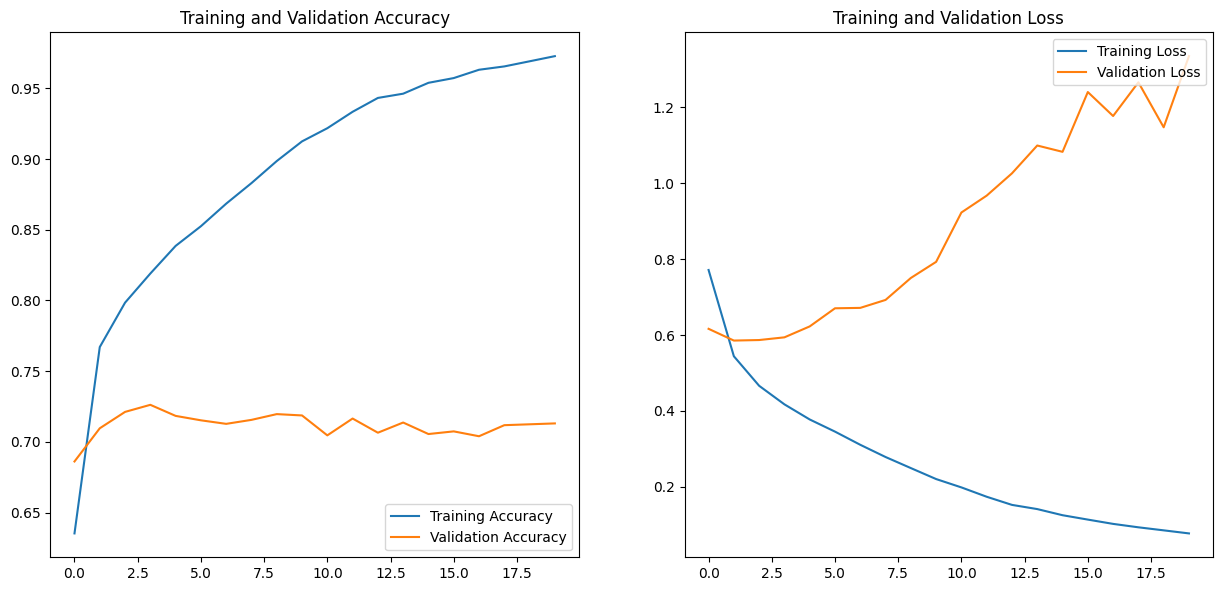

In [27]:
plot_curves(history)


100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

f_beta score = 0.6693112152902994
Cohen's Kappa score = 0.42061570992630803
                    precision    recall  f1-score   support

Negative (Class 0)       0.69      0.81      0.75      1667
Positive (Class 1)       0.75      0.61      0.67      1529

          accuracy                           0.71      3196
         macro avg       0.72      0.71      0.71      3196
      weighted avg       0.72      0.71      0.71      3196



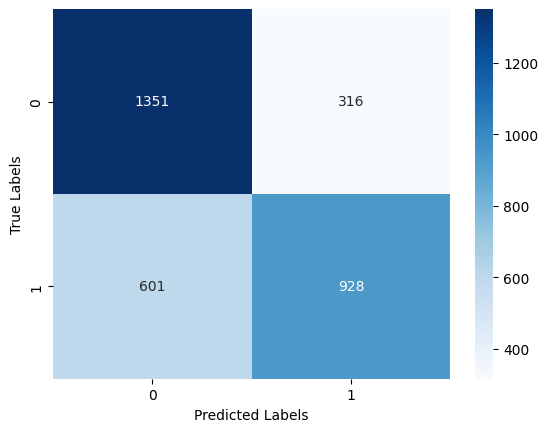

In [13]:
prediction_and_evaluation(model,X_test=X_test,y_test=y_test)

In [32]:
np.unique(y_train)

array([0., 1.])

In [14]:
def find_distribution(array):
    # Get unique values and their counts
    unique_values, counts = np.unique(array, return_counts=True)

    # Print the results
    for value, count in zip(unique_values, counts):
        print(f"Value {value} appears {count} times")

In [43]:
find_distribution(y_train)

Value 0.0 appears 40315 times
Value 1.0 appears 40315 times


In [15]:
find_distribution(y_test)

Value 0.0 appears 3196 times
Value 1.0 appears 3196 times


In [44]:
find_distribution(y_valid)

Value 0.0 appears 3196 times
Value 1.0 appears 3196 times
